In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import Dense, BatchNormalization, ZeroPadding1D

def create_base_model(input_shape=(720, 2)):
    """
    Creates the Base CNN model as described in the research paper.
    This model acts as the feature extractor.
    
    Architecture based on Section 4.2 and Figure 8.
    """
    
    # Define the input layer
    input_tensor = Input(shape=input_shape, name='input_signal')
    
    # 1. Batch Normalization
    x = BatchNormalization()(input_tensor) # [cite: 380]
    
    # 2. Zero Padding
    x = ZeroPadding1D(padding=2)(x) # [cite: 382]
    
    # 3. First Conv Layer
    # Text says 64 filters, size 2 [cite: 384]
    x = Conv1D(filters=64, kernel_size=2, activation='relu', name='conv1d_1')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_1')(x) # 
    
    # 4. Second Conv Layer
    # Text says 64 filters, size 4 [cite: 384]
    x = Conv1D(filters=64, kernel_size=4, activation='relu', name='conv1d_2')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_2')(x) # 
    
    # 5. Third Conv Layer
    # Text says 32 filters, size 16 [cite: 385]
    x = Conv1D(filters=32, kernel_size=16, activation='relu', name='conv1d_3')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_3')(x) # 
    
    # 6. Fourth Conv Layer
    # Text says 32 filters, size 32 [cite: 385]
    x = Conv1D(filters=32, kernel_size=32, activation='relu', name='conv1d_4')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_4')(x) # 
    
    # 7. Flatten
    x = Flatten(name='flatten')(x) # [cite: 385]
    
    # 8. Dense Layer
    # 256 neurons, sigmoid activation [cite: 385]
    x = Dense(units=256, activation='sigmoid', name='dense_256')(x)
    
    # 9. Output (Embedding) Layer
    # 256 units, no activation. This is the final embedding vector. [cite: 386]
    embedding_output = Dense(units=256, name='embedding_output')(x)
    
    # Create the model
    model = Model(inputs=input_tensor, outputs=embedding_output, name='Base_CNN_Model')
    
    return model

# --- Let's create the model and see its summary ---
base_model = create_base_model()

print("✅ Base CNN Model Created Successfully!")
base_model.summary()

✅ Base CNN Model Created Successfully!


Model: "Base_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_signal (InputLayer)       │ (None, 720, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 720, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding1d_3                │ (None, 724, 2)         │             0 │
│ (ZeroPadding1D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 723, 64)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 361, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 358, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 179, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 164, 32)        │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling1D)        │ (None, 82, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 51, 32)         │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_4 (MaxPooling1D)        │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_output (Dense)        │ (None, 256)            │        65,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,224 (1.35 MB)

 Trainable params: 353,220 (1.35 MB)

 Non-trainable params: 4 (16.00 B)

In [10]:
from tensorflow.keras.layers import Lambda
import tensorflow.keras.backend as K

def create_siamese_network(base_model, input_shape=(720, 2)):
    """
    Creates the full Siamese Network model.
    It takes two inputs, passes them through the *same* base_model,
    and calculates the L1 distance between their embeddings.
    """
    
    # Define the two input layers
    input_a = Input(shape=input_shape, name='input_A')
    input_b = Input(shape=input_shape, name='input_B')
    
    # Pass both inputs through the *identical* base model
    # This is the "shared parameters" part
    embedding_a = base_model(input_a)
    embedding_b = base_model(input_b)
    
    # Define a custom Lambda layer to calculate L1 distance
    # This implements Equation (8) from the paper [cite: 395]
    L1_distance_layer = Lambda(
        lambda tensors: K.sum(K.abs(tensors[0] - tensors[1]), axis=-1, keepdims=True),
        name='L1_distance'
    )
    
    # Calculate the distance
    distance = L1_distance_layer([embedding_a, embedding_b])
    
    # Create the final model
    # Inputs: [input_a, input_b]
    # Output: distance
    siamese_model = Model(inputs=[input_a, input_b], outputs=distance, name='Siamese_Model')
    
    return siamese_model

# --- Create the full Siamese model ---
siamese_model = create_siamese_network(base_model)

print("\n\n✅ Full Siamese Model Created Successfully!")
siamese_model.summary()



✅ Full Siamese Model Created Successfully!


Model: "Siamese_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_A             │ (None, 720, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_B             │ (None, 720, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Base_CNN_Model      │ (None, 256)       │    353,224 │ input_A[0][0],    │
│ (Functional)        │                   │            │ input_B[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ L1_distance         │ (None, 1)         │          0 │ Base_CNN_Model[0… │
│ (Lambda)            │                   │            │ Base_CNN_Model[1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 353,224 (1.35 MB)

 Trainable params: 353,220 (1.35 MB)

 Non-trainable params: 4 (16.00 B)

In [11]:
import tensorflow as tf
import tensorflow.keras.backend as K
import numpy as np

# We'll need the training data we prepared in the previous step
# (X_train, y_train, etc.)

def create_contrastive_loss(margin=6.5):
    """
    Creates the contrastive loss function with a specified margin.
    This is based on Equation (9) in the paper.
    
    Args:
        margin (float): The margin 'm' from the paper.
    """
    
    def contrastive_loss(y_true, y_pred):
        """
        y_true: The label (1 for similar, 0 for dissimilar)
        y_pred: The L1 distance (D) output by the Siamese model
        """
        y_true = tf.cast(y_true, tf.float32)
        
        # Loss for similar pairs (y=1)
        # L = 1/2 * D^2
        loss_similar = 0.5 * K.square(y_pred)
        
        # Loss for dissimilar pairs (y=0)
        # L = 1/2 * max(0, m - D)^2
        loss_dissimilar = 0.5 * K.square(K.maximum(0.0, margin - y_pred))
        
        # Combine the losses
        # L = y * L_similar + (1-y) * L_dissimilar
        loss = (y_true * loss_similar) + ((1.0 - y_true) * loss_dissimilar)
        
        return K.mean(loss)
        
    return contrastive_loss

# --- Create the loss function with the paper's optimal margin ---
contrastive_loss_fn = create_contrastive_loss(margin=6.5)

print("✅ Contrastive Loss function created.")

✅ Contrastive Loss function created.


In [12]:
def create_data_pairs(X, y):
    """
    Creates positive and negative pairs from the input data.
    X: The data (e.g., X_train)
    y: The labels (e.g., y_train)
    """
    print(f"Generating data pairs from {X.shape[0]} samples...")
    
    pairs_a = []
    pairs_b = []
    labels = []
    
    # Create a dictionary to map each class label to its indices
    class_indices = {label: np.where(y == label)[0] for label in np.unique(y)}
    num_classes = len(class_indices)
    
    for idx1 in range(len(X)):
        # Get the current sample and its label
        current_sample = X[idx1]
        label = y[idx1]
        
        # --- 1. Create a POSITIVE pair (label = 1) ---
        # Find another random sample from the SAME class
        idx2 = np.random.choice(class_indices[label])
        # Make sure it's not the same sample
        while idx2 == idx1:
            idx2 = np.random.choice(class_indices[label])
        
        positive_sample = X[idx2]
        
        pairs_a.append(current_sample)
        pairs_b.append(positive_sample)
        labels.append(1.0)
        
        # --- 2. Create a NEGATIVE pair (label = 0) ---
        # Find a random class that is DIFFERENT from the current one
        negative_label = np.random.randint(0, num_classes)
        while negative_label == label:
            negative_label = np.random.randint(0, num_classes)
            
        # Pick a random sample from that different class
        idx3 = np.random.choice(class_indices[negative_label])
        negative_sample = X[idx3]
        
        pairs_a.append(current_sample)
        pairs_b.append(negative_sample)
        labels.append(0.0)
        
    print("Pair generation complete.")
    
    # Convert lists to NumPy arrays
    return np.array(pairs_a), np.array(pairs_b), np.array(labels)


# --- Generate the training pairs ---
# This assumes you have X_train and y_train from the previous step
# (This may take a moment to run if X_train is large)

# X_train, y_train = ... (from previous data prep code)
# pair_a_train, pair_b_train, labels_train = create_data_pairs(X_train, y_train)

# print(f"\nTraining Pairs Shapes:")
# print(f"Pair A: {pair_a_train.shape}")
# print(f"Pair B: {pair_b_train.shape}")
# print(f"Labels: {labels_train.shape}")

# Note: You should also do this for your validation set to monitor the loss
# X_val_known, y_val_known = ... (from previous data prep code)
# pair_a_val, pair_b_val, labels_val = create_data_pairs(X_val_known, y_val_known)

In [13]:
# --- 1. Compile the model ---
siamese_model.compile(optimizer='adam', loss=contrastive_loss_fn)

print("\nModel compiled successfully.")

# --- 2. Train the model ---
# This is a conceptual example. 
# You need to run the `create_data_pairs` function first.
"""
print("Starting model training...")

history = siamese_model.fit(
    [pair_a_train, pair_b_train],  # Note: Inputs are a list
    labels_train,
    validation_data=(
        [pair_a_val, pair_b_val],  # Validation inputs are also a list
        labels_val
    ),
    batch_size=32,  # You can tune this
    epochs=100      # The paper trained for 100 epochs
)

print("Training complete!")

# --- 3. Save the trained models ---
# The most important part is the base_model, which is your feature extractor
base_model.save('base_model.h5')
siamese_model.save('siamese_model.h5')
print("Trained base_model and siamese_model saved.")
"""


Model compiled successfully.


'\nprint("Starting model training...")\n\nhistory = siamese_model.fit(\n    [pair_a_train, pair_b_train],  # Note: Inputs are a list\n    labels_train,\n    validation_data=(\n        [pair_a_val, pair_b_val],  # Validation inputs are also a list\n        labels_val\n    ),\n    batch_size=32,  # You can tune this\n    epochs=100      # The paper trained for 100 epochs\n)\n\nprint("Training complete!")\n\n# --- 3. Save the trained models ---\n# The most important part is the base_model, which is your feature extractor\nbase_model.save(\'base_model.h5\')\nsiamese_model.save(\'siamese_model.h5\')\nprint("Trained base_model and siamese_model saved.")\n'

In [14]:
import scipy.io
import numpy as np
import os
from sklearn.model_selection import train_test_split

# --- 1. Load Data ---
dataset_path = "E:\\RF FINGERPRINTING\\dataset\\"
all_data = {}
device_files = [f"Device_{i}.mat" for i in range(1, 11)]

print("Loading data...")
for file_name in device_files:
    file_path = os.path.join(dataset_path, file_name)
    mat_data = scipy.io.loadmat(file_path)
    all_data[file_name] = mat_data['headerIQMatrix']
print(f"Successfully loaded {len(all_data)} device files.\n")

# --- 2. Preprocessing: Split I/Q and Merge ---
num_frames_to_merge = 10
processed_data = {}

print("Preprocessing data...")
for device_name, complex_data in all_data.items():
    i_data = np.real(complex_data)
    q_data = np.imag(complex_data)
    iq_data = np.stack([i_data, q_data], axis=-1)
    
    total_frames = iq_data.shape[0]
    samples_per_frame = iq_data.shape[1]
    iq_dim = iq_data.shape[2]
    new_num_frames = total_frames // num_frames_to_merge
    truncated_data = iq_data[:new_num_frames * num_frames_to_merge]
    
    reshaped_data = truncated_data.reshape(new_num_frames, num_frames_to_merge, samples_per_frame, iq_dim)
    merged_data = reshaped_data.reshape(new_num_frames, num_frames_to_merge * samples_per_frame, iq_dim)
    
    processed_data[device_name] = merged_data
print("All data has been preprocessed.\n")

# --- 3. Organize for Training ---
known_device_keys = ['Device_1.mat', 'Device_2.mat', 'Device_5.mat', 
                     'Device_6.mat', 'Device_7.mat', 'Device_8.mat', 'Device_9.mat']
unknown_device_keys = ['Device_3.mat', 'Device_4.mat']
validation_device_key = 'Device_10.mat'

# --- 3a. Create 'Known Device' pool ---
X_known_list = []
y_known_list = []

for label, key in enumerate(known_device_keys):
    device_data = processed_data[key]
    X_known_list.append(device_data)
    y_known_list.append(np.full(device_data.shape[0], label))

X_known_pool = np.concatenate(X_known_list, axis=0)
y_known_pool = np.concatenate(y_known_list, axis=0)
print(f"Created 'Known Device' pool with shape: {X_known_pool.shape}")

# --- 3b. Split the 'Known Device' pool ---
print("Splitting data into train, validation, and test sets...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X_known_pool, y_known_pool, test_size=0.3, random_state=42, stratify=y_known_pool
)
X_val_known, X_test_known, y_val_known, y_test_known = train_test_split(
    X_temp, y_temp, test_size=0.67, random_state=42, stratify=y_temp
)

# --- 3c. Create final Validation and Test sets ---
X_val_unknown = processed_data[validation_device_key]
y_val_unknown = np.full(X_val_unknown.shape[0], len(known_device_keys)) # Assign a new 'unknown' label
X_validation_final = np.concatenate([X_val_known, X_val_unknown], axis=0)
y_validation_final = np.concatenate([y_val_known, y_val_unknown], axis=0)

X_test_unknown_list = [processed_data[key] for key in unknown_device_keys]
X_test_unknown = np.concatenate(X_test_unknown_list, axis=0)
y_test_unknown = np.full(X_test_unknown.shape[0], len(known_device_keys)) # Assign 'unknown' label
X_test_final = np.concatenate([X_test_known, X_test_unknown], axis=0)
y_test_final = np.concatenate([y_test_known, y_test_unknown], axis=0)

print("\n--- Data Preparation Complete! ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val_known shape: {X_val_known.shape}, y_val_known shape: {y_val_known.shape}")
print(f"X_validation_final shape: {X_validation_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")
print("Variables 'X_train' and 'y_train' are now defined.")

Loading data...
Successfully loaded 10 device files.

Preprocessing data...
All data has been preprocessed.

Created 'Known Device' pool with shape: (13944, 720, 2)
Splitting data into train, validation, and test sets...

--- Data Preparation Complete! ---
X_train shape: (9760, 720, 2), y_train shape: (9760,)
X_val_known shape: (1380, 720, 2), y_val_known shape: (1380,)
X_validation_final shape: (3372, 720, 2)
X_test_final shape: (6788, 720, 2)
Variables 'X_train' and 'y_train' are now defined.


In [8]:
import numpy as np

# --- Function to Create Pairs (from previous step) ---
def create_data_pairs(X, y):
    print(f"Generating data pairs from {X.shape[0]} samples...")
    pairs_a = []
    pairs_b = []
    labels = []
    
    class_indices = {label: np.where(y == label)[0] for label in np.unique(y)}
    num_classes = len(class_indices)
    
    for idx1 in range(len(X)):
        current_sample = X[idx1]
        label = y[idx1]
        
        # --- 1. Create a POSITIVE pair (label = 1) ---
        idx2 = np.random.choice(class_indices[label])
        while idx2 == idx1:
            idx2 = np.random.choice(class_indices[label])
        positive_sample = X[idx2]
        
        pairs_a.append(current_sample)
        pairs_b.append(positive_sample)
        labels.append(1.0)
        
        # --- 2. Create a NEGATIVE pair (label = 0) ---
        negative_label = np.random.randint(0, num_classes)
        while negative_label == label:
            negative_label = np.random.randint(0, num_classes)
        idx3 = np.random.choice(class_indices[negative_label])
        negative_sample = X[idx3]
        
        pairs_a.append(current_sample)
        pairs_b.append(negative_sample)
        labels.append(0.0)
        
    print(f"Pair generation complete for {len(labels)} pairs.")
    return np.array(pairs_a), np.array(pairs_b), np.array(labels)

# --- 1. Generate the Training Pairs ---
# (This assumes X_train and y_train exist)
print("--- Generating Training Pairs ---")
pair_a_train, pair_b_train, labels_train = create_data_pairs(X_train, y_train)
print(f"Training Pairs Shapes: A:{pair_a_train.shape}, B:{pair_b_train.shape}, Labels:{labels_train.shape}")


# --- 2. Generate the Validation Pairs ---
# (This assumes X_val_known and y_val_known exist)
# We use only the *known* devices for the validation loss calculation
print("\n--- Generating Validation Pairs ---")
pair_a_val, pair_b_val, labels_val = create_data_pairs(X_val_known, y_val_known)
print(f"Validation Pairs Shapes: A:{pair_a_val.shape}, B:{pair_b_val.shape}, Labels:{labels_val.shape}")


# --- 3. Start Model Training ---
print("\n--- Starting Model Training (100 Epochs) ---")
# (This assumes 'siamese_model' is compiled)

history = siamese_model.fit(
    [pair_a_train, pair_b_train],  # Inputs are a list
    labels_train,
    validation_data=(
        [pair_a_val, pair_b_val],  # Validation inputs are also a list
        labels_val
    ),
    batch_size=32,
    epochs=100  # As per the paper
)

print("\n--- Training Complete! ---")

# --- 4. Save the Trained Models ---
# The base_model is the most important part!
base_model.save('base_model.h5')
siamese_model.save('siamese_model.h5')

print("\n✅ Trained base_model.h5 and siamese_model.h5 saved to disk.")
print("The 'base_model.h5' file is your trained feature extractor.")

--- Generating Training Pairs ---
Generating data pairs from 9760 samples...
Pair generation complete for 19520 pairs.
Training Pairs Shapes: A:(19520, 720, 2), B:(19520, 720, 2), Labels:(19520,)

--- Generating Validation Pairs ---
Generating data pairs from 1380 samples...
Pair generation complete for 2760 pairs.
Validation Pairs Shapes: A:(2760, 720, 2), B:(2760, 720, 2), Labels:(2760,)

--- Starting Model Training (100 Epochs) ---
Epoch 1/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 1.0754 - val_loss: 0.4262
Epoch 2/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.2561 - val_loss: 0.2311
Epoch 3/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.1521 - val_loss: 0.1991
Epoch 4/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - loss: 0.1079 - val_loss: 0.1109
Epoch 5/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 66s 108ms/step - loss: 0.0673 - val_loss: 0.1034
Epoch 6/100
610/610 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - loss: 0.0427 - val_loss: 0.0461
Epoch 7/100
610/610 ━━━━━━


--- Training Complete! ---

✅ Trained base_model.h5 and siamese_model.h5 saved to disk.
The 'base_model.h5' file is your trained feature extractor.


In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# --- 1. Define L1 Distance Function ---
def l1_distance(embedding_a, embedding_b):
    """Calculates the L1 (Manhattan) distance between two embeddings."""
    return np.sum(np.abs(embedding_a - embedding_b), axis=-1)

# --- 2. Load your TRAINED Base Model ---
# This is your feature extractor
try:
    base_model = load_model('base_model.h5', compile=False)
    print("✅ Successfully loaded 'base_model.h5'")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure 'base_model.h5' is in the same directory.")

# --- 3. Calculate Average Embeddings for Known Classes ---
# This is Step 2 of the SBEC algorithm
print("Calculating average embeddings for known devices...")

# Get all unique *known* class labels from y_train (e.g., 0, 1, 2, 3, 4, 5, 6)
known_labels = np.unique(y_train)
average_embeddings = {}

# Get the embeddings for the entire training set
train_embeddings = base_model.predict(X_train)

for label in known_labels:
    # Get embeddings for all samples of the current class
    class_embeddings = train_embeddings[y_train == label]
    
    # Calculate the average embedding for this class
    average_embeddings[label] = np.mean(class_embeddings, axis=0)

print(f"✅ Calculated {len(average_embeddings)} average embeddings.")

✅ Successfully loaded 'base_model.h5'
Calculating average embeddings for known devices...
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
✅ Calculated 7 average embeddings.



Finding optimal threshold using validation set...
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
✅ Optimal Threshold found: 0.0243 (with F1-score: 0.6059)


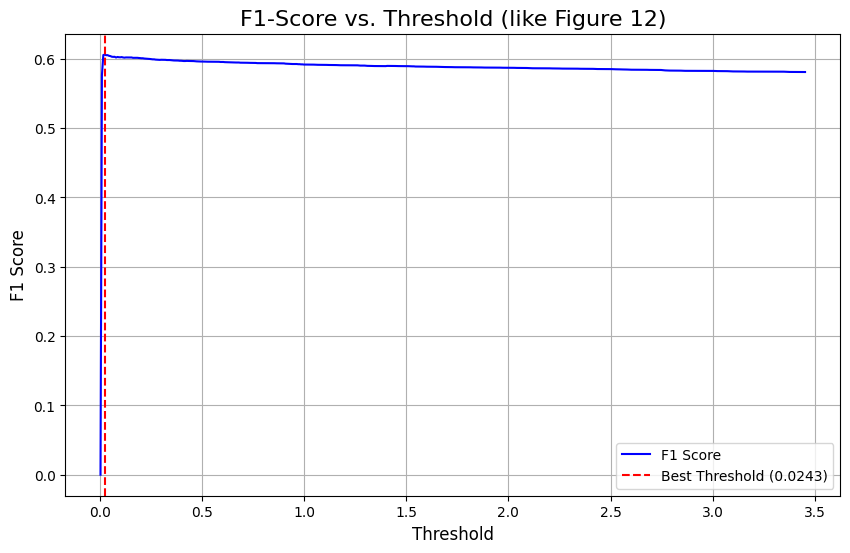

✅ Saved 'f1_vs_threshold.png'


In [16]:
def find_optimal_threshold(base_model, avg_embeddings, X_val, y_val):
    """
    Calculates the best threshold for separating known/unknown devices.
    This replicates Figure 12 from the paper.
    """
    print("\nFinding optimal threshold using validation set...")
    
    # Get embeddings for the entire validation set
    val_embeddings = base_model.predict(X_val)
    
    # Get the 'unknown' label (should be the highest number, e.g., 7)
    unknown_label = np.max(y_val)
    
    # Create true binary labels: 1 for known, 0 for unknown
    y_true_binary = (y_val != unknown_label).astype(int)
    
    min_similarity_scores = []
    
    # Calculate MSS for every validation sample
    for emb in val_embeddings:
        distances = []
        for label, avg_emb in avg_embeddings.items():
            dist = l1_distance(emb, avg_emb)
            distances.append(dist)
        # Store the minimum distance (MSS)
        min_similarity_scores.append(np.min(distances))
    
    min_similarity_scores = np.array(min_similarity_scores)
    
    # Test 500 thresholds, as the paper did
    thresholds = np.linspace(np.min(min_similarity_scores), 
                             np.max(min_similarity_scores), 
                             500)
    
    best_f1 = 0
    best_threshold = 0
    f1_scores = []
    
    for t in thresholds:
        # Predict: 1 if MSS < t (known), 0 if MSS >= t (unknown)
        y_pred_binary = (min_similarity_scores < t).astype(int)
        
        # Calculate f1-score for this threshold
        score = f1_score(y_true_binary, y_pred_binary, pos_label=1)
        f1_scores.append(score)
        
        if score > best_f1:
            best_f1 = score
            best_threshold = t
            
    print(f"✅ Optimal Threshold found: {best_threshold:.4f} (with F1-score: {best_f1:.4f})")
    
    # --- Plot the F1-Score vs. Threshold (Figure 12) ---
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1 Score', color='blue')
    plt.axvline(best_threshold, color='red', linestyle='--', 
                label=f'Best Threshold ({best_threshold:.4f})')
    plt.title('F1-Score vs. Threshold (like Figure 12)', fontsize=16)
    plt.xlabel('Threshold', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig('f1_vs_threshold.png')
    plt.show()
    print("✅ Saved 'f1_vs_threshold.png'")
    
    return best_threshold

# --- Run the function ---
# This assumes 'base_model', 'average_embeddings', 
# 'X_validation_final', and 'y_validation_final' exist
optimal_threshold = find_optimal_threshold(base_model, average_embeddings, 
                                           X_validation_final, y_validation_final)

stricter_threshold = optimal_threshold * 0.7


Testing with Stricter Threshold: 0.0170

--- Evaluating on Final Test Set ---
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

--- Classification Report (like Figure 15) ---
              precision    recall  f1-score   support

    Device 1       0.30      0.96      0.46       400
    Device 2       1.00      0.94      0.97       400
    Device 3       1.00      0.95      0.97       401
    Device 4       1.00      0.96      0.98       400
    Device 5       1.00      0.96      0.98       401
    Device 6       0.94      0.97      0.96       401
    Device 7       1.00      0.94      0.97       401
     Unknown       0.96      0.77      0.85      3984

    accuracy                           0.85      6788
   macro avg       0.90      0.93      0.89      6788
weighted avg       0.93      0.85      0.87      6788


Generating Confusion Matrix (like Figure 14)...


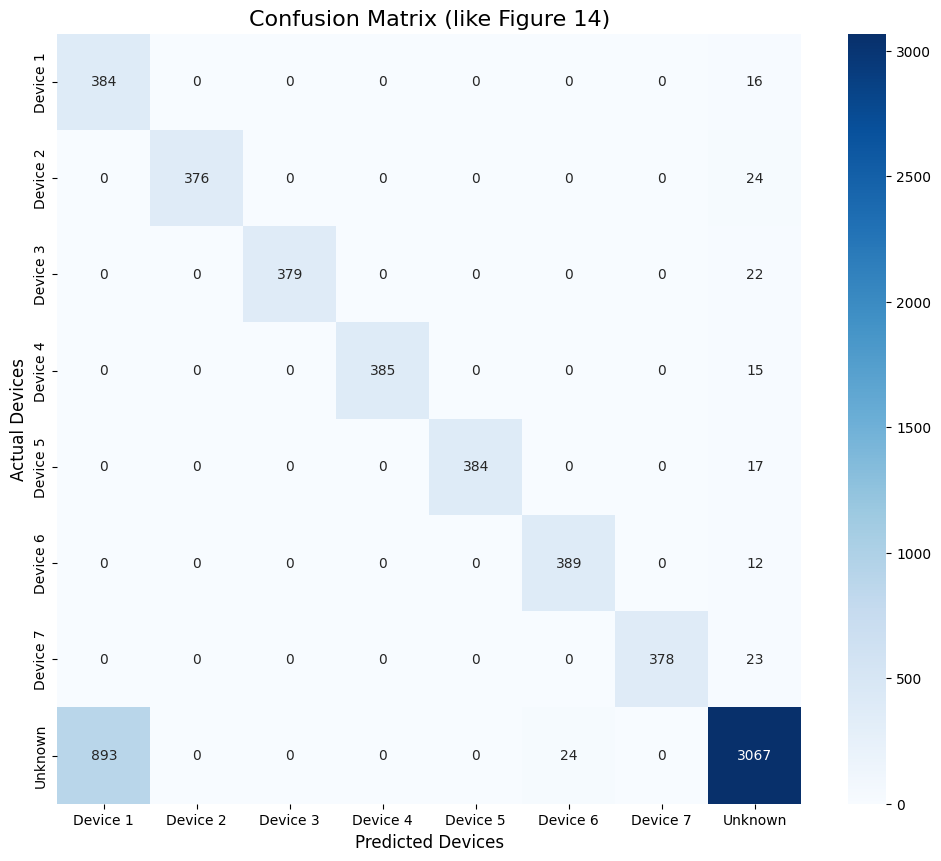

✅ Saved 'confusion_matrix.png'


In [17]:
def evaluate_on_test_set(base_model, avg_embeddings, threshold, X_test, y_test):
    """
    Classifies the test set using the SBEC algorithm and optimal threshold.
    Generates the final classification report and confusion matrix.
    """
    print("\n--- Evaluating on Final Test Set ---")
    
    # Get embeddings for the test set
    test_embeddings = base_model.predict(X_test)
    
    known_labels = list(avg_embeddings.keys())
    # Create labels for display (e.g., 'Device 1', 'Device 2', ..., 'Unknown')
    class_names = [f"Device {l+1}" for l in known_labels] + ["Unknown"]
    
    # Get the 'unknown' label (e.g., 7)
    unknown_label = np.max(y_test)
    
    y_predictions = []
    
    # --- SBEC Algorithm (Step 2-5) ---
    for emb in test_embeddings:
        distances = []
        labels_sorted = []
        for label, avg_emb in avg_embeddings.items():
            dist = l1_distance(emb, avg_emb)
            distances.append(dist)
            labels_sorted.append(label)
            
        # Find the Minimum Similarity Score (MSS) and its corresponding class
        min_dist = np.min(distances)
        pred_label = labels_sorted[np.argmin(distances)]
        
        # --- The Threshold Check ---
        if min_dist >= threshold:
            # If distance is too high, classify as 'Unknown'
            y_predictions.append(unknown_label)
        else:
            # Otherwise, classify as the closest known device
            y_predictions.append(pred_label)
            
    y_predictions = np.array(y_predictions)
    
    # --- 1. Print Classification Report (like Figure 15) ---
    print("\n--- Classification Report (like Figure 15) ---")
    # We replace the integer labels (0-7) with names for clarity
    y_test_names = [class_names[l] for l in y_test]
    y_pred_names = [class_names[l] for l in y_predictions]
    
    print(classification_report(y_test_names, y_pred_names, labels=class_names))

    # --- 2. Generate Confusion Matrix (like Figure 14) ---
    print("\nGenerating Confusion Matrix (like Figure 14)...")
    cm = confusion_matrix(y_test_names, y_pred_names, labels=class_names)
    
    # Plotting the confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (like Figure 14)', fontsize=16)
    plt.ylabel('Actual Devices', fontsize=12)
    plt.xlabel('Predicted Devices', fontsize=12)
    plt.savefig('confusion_matrix.png')
    plt.show()
    print("✅ Saved 'confusion_matrix.png'")

# --- Run the final evaluation ---
# This assumes all variables from previous steps are available
print(f"Testing with Stricter Threshold: {stricter_threshold:.4f}")

# Re-run evaluation with the new threshold
evaluate_on_test_set(base_model, average_embeddings, stricter_threshold,
                       X_test_final, y_test_final)

In [ ]:
import matplotlib.pyplot as plt

# This code assumes you have just finished training and have the 'history' variable
# If you lost the variable, you would need to re-train the model.

print("Generating training loss plot...")

plt.figure(figsize=(10, 6))

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

plt.title('Siamese Network Training Learning Curve', fontsize=16)
plt.xlabel('Number of Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the figure
plt.savefig('training_loss_curve.png', dpi=300)
print("✅ Saved 'training_loss_curve.png'")

# Show the plot
plt.show()

In [22]:
import random

def demo_single_prediction(base_model, avg_embeddings, threshold, X_test, y_test):
    """
    Simulates a real-time authentication request.
    Picks a random sample and decides: Access Granted or Denied?
    """
    print("\n--- 🔒 Simulation: Incoming Connection Request ---")
    
    # 1. Pick a random sample
    idx = random.randint(0, len(X_test) - 1)
    sample = X_test[idx:idx+1] # Keep shape (1, 720, 2)
    true_label = y_test[idx]
    
    # Determine the true name
    # (Assuming 0-6 are known devices, 7 is Unknown)
    if true_label < len(avg_embeddings):
        true_name = f"Device {true_label + 1}"
        status = "Legitimate Device"
    else:
        true_name = "Unknown/Rogue"
        status = "Intruder!"

    print(f"Incoming Signal ID: #{idx}")
    print(f"True Identity:      {true_name} ({status})")
    
    # 2. Generate Embedding
    embedding = base_model.predict(sample, verbose=0)
    
    # 3. Calculate Distances
    distances = []
    labels_sorted = []
    for label, avg_emb in avg_embeddings.items():
        dist = np.sum(np.abs(embedding - avg_emb)) # L1 distance
        distances.append(dist)
        labels_sorted.append(label)
    
    min_dist = np.min(distances)
    closest_device_idx = np.argmin(distances)
    closest_device_label = labels_sorted[closest_device_idx]
    
    print(f"\n--- Analysis ---")
    print(f"Closest Match:      Device {closest_device_label + 1}")
    print(f"Similarity Score:   {min_dist:.4f} (Lower is better)")
    print(f"Security Threshold: {threshold:.4f}")
    
    # 4. Decision
    print(f"\n--- 🛡️ Firewall Decision ---")
    if min_dist < threshold:
        print(f"✅ ACCESS GRANTED: Authenticated as Device {closest_device_label + 1}")
        
        # Verification for your own sanity
        if true_label == closest_device_label:
            print("(Correct Decision)")
        else:
            print("(Incorrect Decision - False Acceptance)")
            
    else:
        print(f"🚫 ACCESS DENIED: Device Unrecognized")
        
        if true_label >= len(avg_embeddings):
             print("(Correct Decision - Intruder Blocked)")
        else:
             print("(Incorrect Decision - False Rejection)")

# Run the demo
demo_single_prediction(base_model, average_embeddings, stricter_threshold, 
                       X_test_final, y_test_final)


--- 🔒 Simulation: Incoming Connection Request ---
Incoming Signal ID: #865
True Identity:      Device 4 (Legitimate Device)

--- Analysis ---
Closest Match:      Device 4
Similarity Score:   0.0059 (Lower is better)
Security Threshold: 0.0170

--- 🛡️ Firewall Decision ---
✅ ACCESS GRANTED: Authenticated as Device 4
(Correct Decision)
